# Taller 02 — Transfer Learning y Modelos Pre-entrenados en Diagnóstico Dermatológico

Este notebook resuelve el **Taller / Caso de Estudio 02** sobre **DermaMNIST**, incorporando:

- comparación **bilinear vs. bicubic** para el escalado de imágenes 28×28 → 224×224,
- discusión y evidencia de **domain shift**,
- **transfer learning** con **MobileNetV2** en dos fases:
  - **Feature Extraction** (base congelada),
  - **Fine-Tuning** (descongelando los últimos bloques),
- comparación multimodelo entre una **CNN baseline** y modelos pre-entrenados,
- comparación entre una **CNN tradicional** y una **arquitectura basada en atención** (**DeiT-tiny / ViT compacto**),
- enfoque híbrido opcional **CNN features + Random Forest**,
- métricas por clase, con énfasis en **melanoma (`mel`)**,
- exportación del **mejor modelo** y generación de **`predict.py`**.

> Recomendación: primero ejecuta el notebook en `FAST_MODE=True` para verificar que todo corre.  
> Para resultados de entrega, cambia `FAST_MODE=False`.


## Lo que exige el taller

Este caso pide trabajar con **DermaMNIST (7 clases)**, implementar **upsampling** para modelos pre-entrenados, comparar al menos **dos arquitecturas** y analizar el compromiso entre **F1 macro**, número de parámetros y tiempo de inferencia. También pide rutinas de **freezing / unfreezing**, matrices de confusión lado a lado, y un **script de inferencia** para imágenes crudas de **28×28**.


In [1]:
# Si estás en Colab / Jupyter limpio, ejecuta esta celda una vez.
# En un entorno ya configurado, puedes omitirla.

%pip install -q medmnist tensorflow keras keras-hub scikit-learn matplotlib seaborn pandas pillow joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.9 MB/s eta 0:00:00


In [2]:
import os
import json
import time
import copy
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import medmnist
from medmnist import INFO

warnings.filterwarnings("ignore")

SEED = 161105
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("MedMNIST:", medmnist.__version__)


TensorFlow: 2.19.0
Keras: 3.13.2
MedMNIST: 3.0.2


In [3]:
# =========================
# Configuración general
# =========================
FAST_MODE = True

DATA_FLAG = "dermamnist"
SOURCE_SIZE = 28            # el problema original del taller
TARGET_SIZE = 224           # resolución requerida por los modelos pre-entrenados
BATCH_SIZE = 32
NUM_CLASSES = 7

MAX_TRAIN_FAST = 1400
MAX_VAL_FAST = 250
MAX_TEST_FAST = 500

EPOCHS_BASELINE = 10 if FAST_MODE else 20
EPOCHS_MOBILENET_FE = 5 if FAST_MODE else 10
EPOCHS_MOBILENET_FT = 5 if FAST_MODE else 10
EPOCHS_DEIT = 4 if FAST_MODE else 8

LEARNING_RATE_BASELINE = 1e-3
LEARNING_RATE_FE = 1e-3
LEARNING_RATE_FT = 1e-5
LEARNING_RATE_DEIT = 5e-5

RUN_HYBRID_RF = True
RUN_DEIT = True
EXPORT_DIR = Path("artifacts_taller_02")
EXPORT_DIR.mkdir(exist_ok=True, parents=True)

print({
    "FAST_MODE": FAST_MODE,
    "TARGET_SIZE": TARGET_SIZE,
    "RUN_HYBRID_RF": RUN_HYBRID_RF,
    "RUN_DEIT": RUN_DEIT,
    "EXPORT_DIR": str(EXPORT_DIR)
})


{'FAST_MODE': True, 'TARGET_SIZE': 224, 'RUN_HYBRID_RF': True, 'RUN_DEIT': True, 'EXPORT_DIR': 'artifacts_taller_02'}


In [4]:
# ======================================
# Descarga / carga de DermaMNIST 28x28
# ======================================
info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

train_data = DataClass(split="train", download=True, size=SOURCE_SIZE, as_rgb=True)
val_data   = DataClass(split="val",   download=True, size=SOURCE_SIZE, as_rgb=True)
test_data  = DataClass(split="test",  download=True, size=SOURCE_SIZE, as_rgb=True)

x_train = train_data.imgs.copy()
y_train = train_data.labels.squeeze().astype("int32")
x_val   = val_data.imgs.copy()
y_val   = val_data.labels.squeeze().astype("int32")
x_test  = test_data.imgs.copy()
y_test  = test_data.labels.squeeze().astype("int32")

label_map = {int(k): v for k, v in info["label"].items()}
class_names = [label_map[i] for i in range(len(label_map))]
mel_idx = next(i for i, name in label_map.items() if "mel" in name.lower())

print("Clases:", class_names)
print("Clase melanoma (mel):", mel_idx, "->", class_names[mel_idx])
print("Train:", x_train.shape, y_train.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)


100%|██████████| 19.7M/19.7M [00:02<00:00, 9.06MB/s]


Clases: ['actinic keratoses and intraepithelial carcinoma', 'basal cell carcinoma', 'benign keratosis-like lesions', 'dermatofibroma', 'melanoma', 'melanocytic nevi', 'vascular lesions']
Clase melanoma (mel): 4 -> melanoma
Train: (7007, 28, 28, 3) (7007,)
Val  : (1003, 28, 28, 3) (1003,)
Test : (2005, 28, 28, 3) (2005,)


In [5]:
def stratified_subset(x, y, max_samples=None, seed=SEED):
    if max_samples is None or len(y) <= max_samples:
        return x, y
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=max_samples, random_state=seed)
    idx, _ = next(splitter.split(np.zeros(len(y)), y))
    return x[idx], y[idx]

if FAST_MODE:
    x_train, y_train = stratified_subset(x_train, y_train, MAX_TRAIN_FAST)
    x_val, y_val     = stratified_subset(x_val, y_val, MAX_VAL_FAST)
    x_test, y_test   = stratified_subset(x_test, y_test, MAX_TEST_FAST)

print("Después de FAST_MODE:")
print("Train:", x_train.shape, y_train.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)


Después de FAST_MODE:
Train: (1400, 28, 28, 3) (1400,)
Val  : (250, 28, 28, 3) (250,)
Test : (500, 28, 28, 3) (500,)


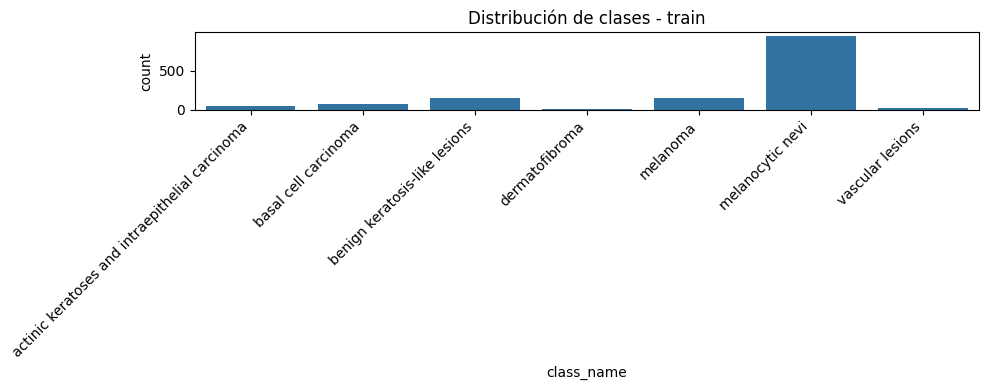

,class_id,count,class_name
0,0,45,actinic keratoses and intraepithelial carcinoma
1,1,72,basal cell carcinoma
2,2,154,benign keratosis-like lesions
3,3,16,dermatofibroma
4,4,155,melanoma
5,5,938,melanocytic nevi
6,6,20,vascular lesions


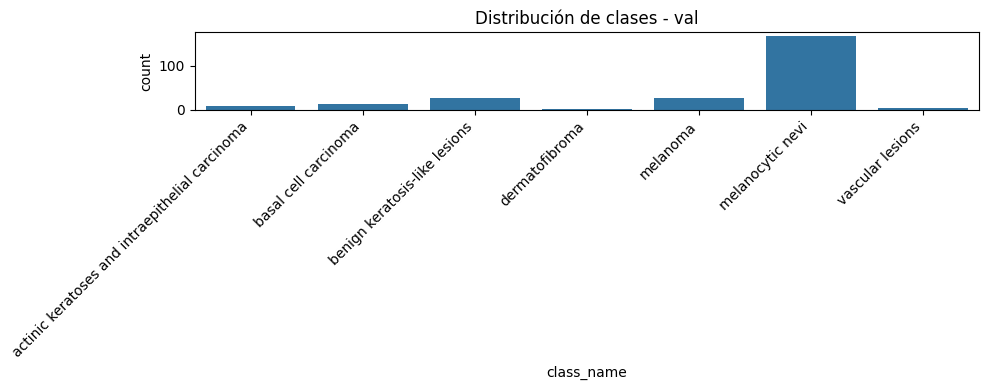

,class_id,count,class_name
0,0,8,actinic keratoses and intraepithelial carcinoma
1,1,13,basal cell carcinoma
2,2,27,benign keratosis-like lesions
3,3,3,dermatofibroma
4,4,28,melanoma
5,5,167,melanocytic nevi
6,6,4,vascular lesions


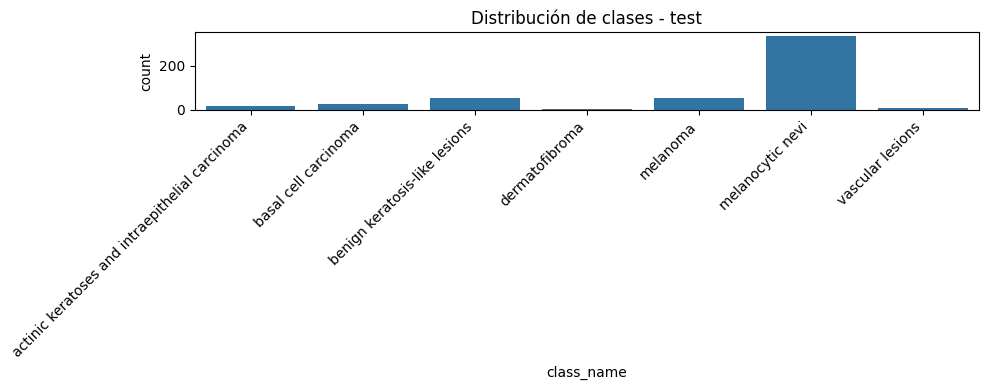

,class_id,count,class_name
0,0,16,actinic keratoses and intraepithelial carcinoma
1,1,26,basal cell carcinoma
2,2,55,benign keratosis-like lesions
3,3,6,dermatofibroma
4,4,56,melanoma
5,5,334,melanocytic nevi
6,6,7,vascular lesions


In [6]:
def plot_class_distribution(y, title):
    counts = pd.Series(y).value_counts().sort_index()
    df = pd.DataFrame({
        "class_id": counts.index,
        "count": counts.values,
        "class_name": [label_map[i] for i in counts.index]
    })
    plt.figure(figsize=(10, 4))
    sns.barplot(data=df, x="class_name", y="count")
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return df

display(plot_class_distribution(y_train, "Distribución de clases - train"))
display(plot_class_distribution(y_val,   "Distribución de clases - val"))
display(plot_class_distribution(y_test,  "Distribución de clases - test"))


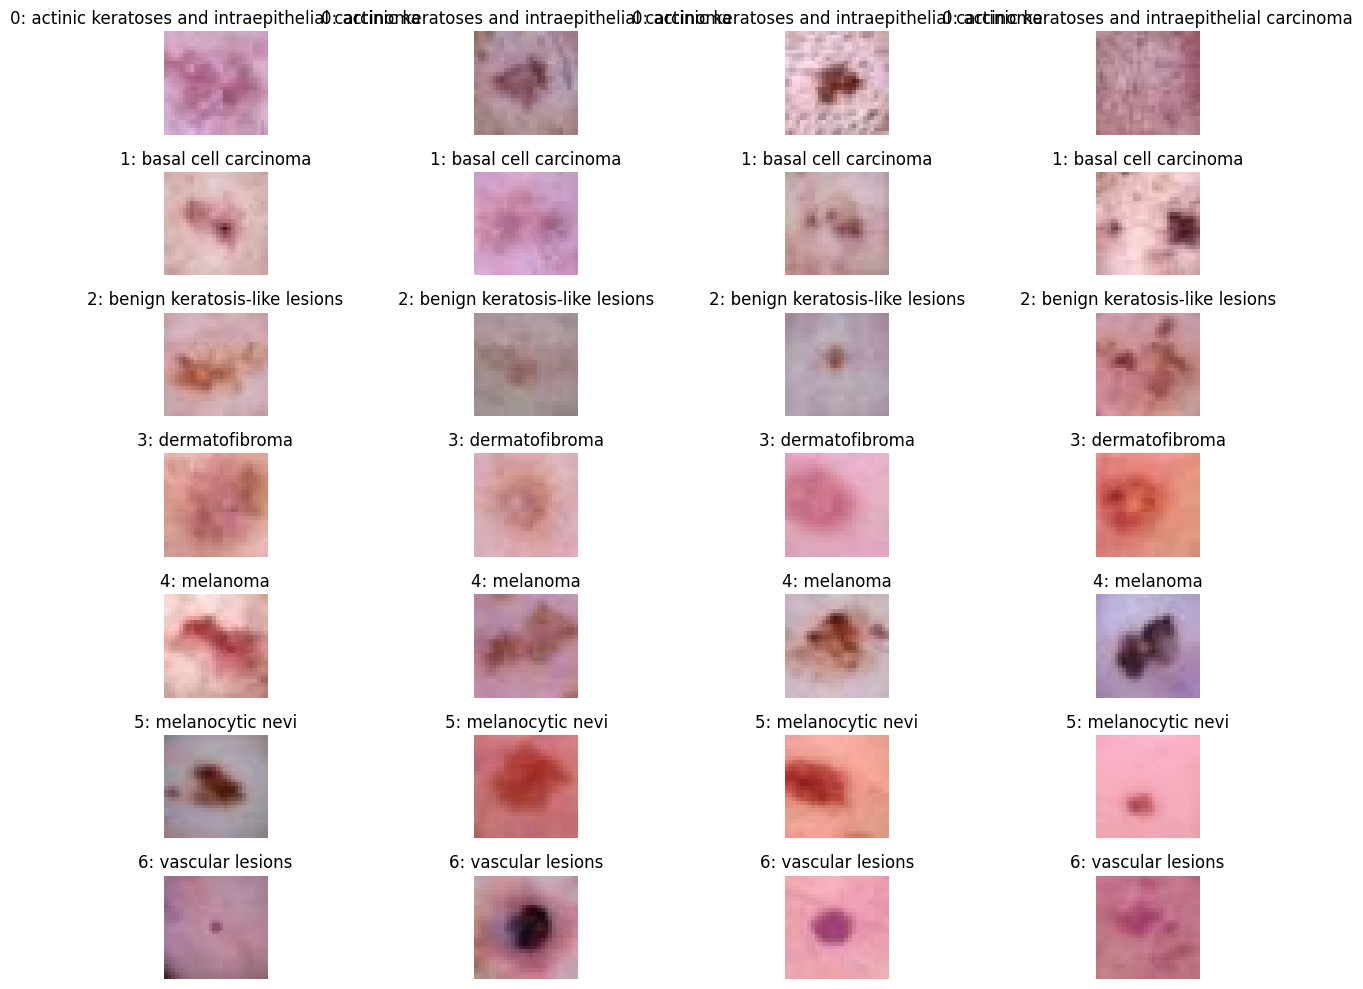

In [7]:
def show_samples_per_class(images, labels, n_per_class=4, figsize=(14, 10)):
    unique_classes = np.unique(labels)
    fig, axes = plt.subplots(len(unique_classes), n_per_class, figsize=figsize)
    if len(unique_classes) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, c in enumerate(unique_classes):
        idx = np.where(labels == c)[0][:n_per_class]
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(idx):
                ax.imshow(images[idx[col]])
                ax.set_title(f"{c}: {label_map[c]}")
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples_per_class(x_train, y_train, n_per_class=4)


## 1. Interpolación: bilinear vs. bicubic

Teóricamente:

- **Bilinear** suele ser más suave y estable, pero puede **lavar bordes** finos.
- **Bicubic** suele preservar mejor continuidad visual y textura aparente, pero puede introducir **ringing / overshoot** alrededor de bordes intensos.

Empíricamente vamos a comparar:

1. visualización de imágenes 28×28 escaladas a 224×224,
2. **error de ida y vuelta** (28→224→28),
3. energía de gradiente aproximada para detectar exceso de suavizado o sobre-realce.


In [8]:
# ===========================================
# Comparación empírica bilinear vs. bicubic
# ===========================================
INTERPOLATIONS = ["bilinear", "bicubic"]

def resize_np(images, size, method="bilinear"):
    images_tf = tf.convert_to_tensor(images, dtype=tf.float32)
    return tf.image.resize(images_tf, (size, size), method=method).numpy()

def gradient_energy(images):
    # images: [N, H, W, C], float32
    gx = np.diff(images, axis=2)
    gy = np.diff(images, axis=1)
    return float(np.mean(gx**2) + np.mean(gy**2))

def roundtrip_metrics(images, method, target_size=224, source_size=28):
    up = resize_np(images, target_size, method=method)
    down = resize_np(up, source_size, method="area")
    mse = float(np.mean((images.astype("float32") - down)**2))
    ge_up = gradient_energy(up)
    ge_down = gradient_energy(down)
    return {
        "interpolation": method,
        "roundtrip_mse": mse,
        "gradient_energy_up": ge_up,
        "gradient_energy_down": ge_down,
    }

sample_n = min(256, len(x_train))
interp_sample = x_train[:sample_n].astype("float32")

interp_results = pd.DataFrame([
    roundtrip_metrics(interp_sample, method=m, target_size=TARGET_SIZE, source_size=SOURCE_SIZE)
    for m in INTERPOLATIONS
]).sort_values("roundtrip_mse")

display(interp_results)


,interpolation,roundtrip_mse,gradient_energy_up,gradient_energy_down
1,bicubic,0.643139,2.429094,136.847275
0,bilinear,2.189961,2.186470,122.519081


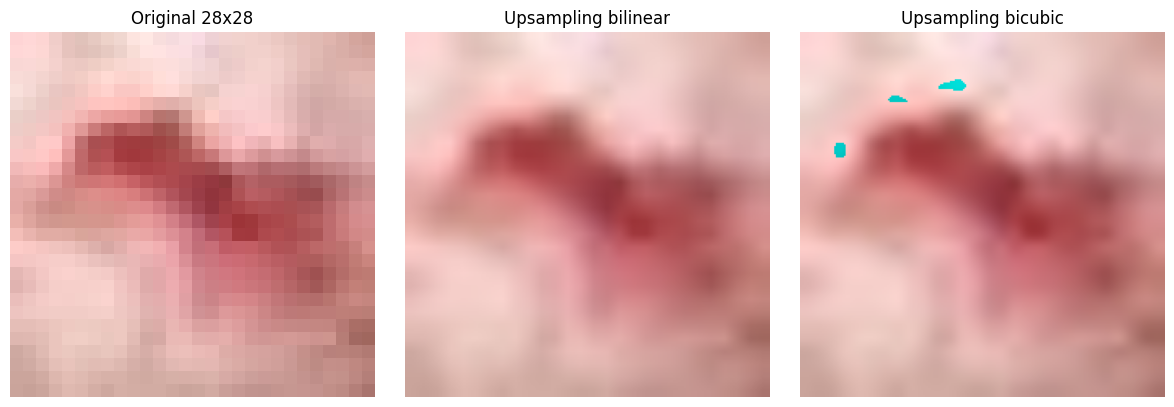

In [9]:
# Visualización lado a lado
example_idx = np.where(y_train == mel_idx)[0][0] if np.any(y_train == mel_idx) else 0
example_img = x_train[example_idx].astype("float32")

resized_bilinear = resize_np(example_img[None, ...], TARGET_SIZE, "bilinear")[0].astype("uint8")
resized_bicubic  = resize_np(example_img[None, ...], TARGET_SIZE, "bicubic")[0].astype("uint8")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(example_img.astype("uint8"))
axes[0].set_title(f"Original {SOURCE_SIZE}x{SOURCE_SIZE}")
axes[1].imshow(resized_bilinear)
axes[1].set_title("Upsampling bilinear")
axes[2].imshow(resized_bicubic)
axes[2].set_title("Upsampling bicubic")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [10]:
# Elegimos automáticamente la interpolación con menor error de ida y vuelta.
SELECTED_INTERPOLATION = interp_results.iloc[0]["interpolation"]
print("Interpolación seleccionada para los modelos pre-entrenados:", SELECTED_INTERPOLATION)


Interpolación seleccionada para los modelos pre-entrenados: bicubic


## 2. Domain shift

Los pesos pre-entrenados en **ImageNet** aprenden filtros útiles de bajo y medio nivel (bordes, texturas, contrastes, composiciones locales). Eso ayuda cuando el dataset dermatológico es pequeño.  
Pero existe **domain shift** porque las imágenes de ImageNet provienen de objetos cotidianos, mientras que aquí interesan **patrones dermatoscópicos finos**: pigmentación, bordes irregulares, simetría, textura vascular, etc.

Implicación práctica:

- en **feature extraction**, la base puede transferir información visual general con poco costo computacional;
- en **fine-tuning**, ajustar los últimos bloques ayuda a especializar la representación a morfología dermatológica;
- aun así, un modelo pequeño y móvil (como MobileNetV2) puede ser preferible para despliegue si conserva buen **F1 macro** y buen **recall para melanoma**.


In [11]:
# ===========================================
# Utilidades de datos y entrenamiento
# ===========================================
AUTOTUNE = tf.data.AUTOTUNE

augmenter_224 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmenter_224")

augmenter_28 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="augmenter_28")

def preprocess_baseline(images):
    images = tf.cast(images, tf.float32) / 255.0
    return images

def preprocess_mobilenet(images):
    images = tf.cast(images, tf.float32)
    return tf.keras.applications.mobilenet_v2.preprocess_input(images)

def resize_images(images, target_size, interpolation):
    images = tf.cast(images, tf.float32)
    return tf.image.resize(images, (target_size, target_size), method=interpolation)

def make_dataset(images, labels, batch_size=32, shuffle=False, model_family="baseline",
                 interpolation="bilinear", augment=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        ds = ds.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    def _map(x, y):
        if model_family == "baseline":
            x = preprocess_baseline(x)
            if augment:
                x = augmenter_28(x, training=True)
        elif model_family == "mobilenet":
            x = resize_images(x, TARGET_SIZE, interpolation)
            if augment:
                x = augmenter_224(x, training=True)
            x = preprocess_mobilenet(x)
        elif model_family == "deit":
            # para modelos KerasHub / ViT usamos imagen redimensionada cruda [0, 255]
            x = resize_images(x, TARGET_SIZE, interpolation)
            if augment:
                x = augmenter_224(x, training=True)
            x = tf.cast(x, tf.float32)
        elif model_family == "hybrid_features":
            x = resize_images(x, TARGET_SIZE, interpolation)
            x = preprocess_mobilenet(x)
        else:
            raise ValueError(f"model_family desconocido: {model_family}")
        return x, y

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_baseline = make_dataset(x_train, y_train, BATCH_SIZE, shuffle=True,  model_family="baseline", augment=True)
val_ds_baseline   = make_dataset(x_val,   y_val,   BATCH_SIZE, shuffle=False, model_family="baseline")
test_ds_baseline  = make_dataset(x_test,  y_test,  BATCH_SIZE, shuffle=False, model_family="baseline")

train_ds_mobilenet = make_dataset(
    x_train, y_train, BATCH_SIZE, shuffle=True, model_family="mobilenet",
    interpolation=SELECTED_INTERPOLATION, augment=True
)
val_ds_mobilenet = make_dataset(
    x_val, y_val, BATCH_SIZE, shuffle=False, model_family="mobilenet",
    interpolation=SELECTED_INTERPOLATION
)
test_ds_mobilenet = make_dataset(
    x_test, y_test, BATCH_SIZE, shuffle=False, model_family="mobilenet",
    interpolation=SELECTED_INTERPOLATION
)

train_ds_deit = make_dataset(
    x_train, y_train, BATCH_SIZE, shuffle=True, model_family="deit",
    interpolation=SELECTED_INTERPOLATION, augment=True
)
val_ds_deit = make_dataset(
    x_val, y_val, BATCH_SIZE, shuffle=False, model_family="deit",
    interpolation=SELECTED_INTERPOLATION
)
test_ds_deit = make_dataset(
    x_test, y_test, BATCH_SIZE, shuffle=False, model_family="deit",
    interpolation=SELECTED_INTERPOLATION
)


In [12]:
# class weights para combatir desbalance
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weight_values)}
class_weight_dict


{0: 4.444444444444445,
 1: 2.7777777777777777,
 2: 1.2987012987012987,
 3: 12.5,
 4: 1.2903225806451613,
 5: 0.21321961620469082,
 6: 10.0}

In [13]:
# ===========================================
# Baseline CNN (aproxima el Caso 01)
# ===========================================
def build_baseline_cnn(input_shape=(28, 28, 3), num_classes=7):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="baseline_cnn_28x28")
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE_BASELINE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_cnn(num_classes=NUM_CLASSES)
baseline_model.summary()


Model: "baseline_cnn_28x28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,047 (371.28 KB)

 Trainable params: 94,599 (369.53 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
callbacks_baseline = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

history_baseline = baseline_model.fit(
    train_ds_baseline,
    validation_data=val_ds_baseline,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weight_dict,
    callbacks=callbacks_baseline,
    verbose=1,
)


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.2907 - loss: 1.8808 - val_accuracy: 0.0320 - val_loss: 2.1549 - learning_rate: 0.0010
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3700 - loss: 1.6294 - val_accuracy: 0.0360 - val_loss: 2.7062 - learning_rate: 0.0010
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3957 - loss: 1.5500 - val_accuracy: 0.0320 - val_loss: 3.3453 - learning_rate: 0.0010
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4271 - loss: 1.4653 - val_accuracy: 0.0360 - val_loss: 4.1779 - learning_rate: 2.0000e-04
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4493 - loss: 1.3679 - val_accuracy: 0.0120 - val_loss: 4.7174 - learning_rate: 2.0000e-04


In [15]:
# ===========================================
# MobileNetV2 — feature extraction
# ===========================================
def build_mobilenet_feature_extractor(num_classes=7, input_shape=(224, 224, 3), dropout=0.3):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="mobilenet_gap")(x)
    x = layers.Dropout(dropout, name="mobilenet_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="mobilenet_predictions")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_feature_extraction")
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE_FE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base

mobilenet_fe_model, mobilenet_base = build_mobilenet_feature_extractor(num_classes=NUM_CLASSES)
mobilenet_fe_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "mobilenetv2_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_gap                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_dropout (Dropout)     │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_predictions (Dense)   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
callbacks_mobilenet_fe = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

history_mobilenet_fe = mobilenet_fe_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=EPOCHS_MOBILENET_FE,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobilenet_fe,
    verbose=1,
)


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 943ms/step - accuracy: 0.2236 - loss: 2.0844 - val_accuracy: 0.2680 - val_loss: 1.7650 - learning_rate: 0.0010
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step - accuracy: 0.3264 - loss: 1.7228 - val_accuracy: 0.4280 - val_loss: 1.5554 - learning_rate: 0.0010
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - accuracy: 0.3929 - loss: 1.6039 - val_accuracy: 0.4560 - val_loss: 1.4860 - learning_rate: 0.0010
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - accuracy: 0.4307 - loss: 1.6019 - val_accuracy: 0.2160 - val_loss: 1.9206 - learning_rate: 0.0010
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.4150 - loss: 1.4954 - val_accuracy: 0.2440 - val_loss: 1.9044 - learning_rate: 0.0010


In [17]:
# Guardamos una copia del modelo al terminar feature extraction,
# para comparar FE vs FT de forma limpia.
mobilenet_fe_snapshot = keras.models.clone_model(mobilenet_fe_model)
mobilenet_fe_snapshot.set_weights(mobilenet_fe_model.get_weights())
mobilenet_fe_snapshot.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE_FE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [18]:
# ===========================================
# MobileNetV2 — fine-tuning
# ===========================================
def unfreeze_mobilenet_last_layers(base_model, trainable_layers=30):
    base_model.trainable = True
    for layer in base_model.layers[:-trainable_layers]:
        layer.trainable = False
    for layer in base_model.layers[-trainable_layers:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

unfreeze_mobilenet_last_layers(mobilenet_base, trainable_layers=30)

mobilenet_fe_model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE_FT),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_mobilenet_ft = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7),
]

history_mobilenet_ft = mobilenet_fe_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=EPOCHS_MOBILENET_FT,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobilenet_ft,
    verbose=1,
)

mobilenet_ft_model = mobilenet_fe_model
mobilenet_ft_model._name = "mobilenetv2_finetuned"


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 653ms/step - accuracy: 0.4014 - loss: 1.6522 - val_accuracy: 0.4400 - val_loss: 1.5878 - learning_rate: 1.0000e-05
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.4314 - loss: 1.4124 - val_accuracy: 0.5120 - val_loss: 1.3362 - learning_rate: 1.0000e-05
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.4400 - loss: 1.3740 - val_accuracy: 0.5000 - val_loss: 1.3158 - learning_rate: 1.0000e-05
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 320ms/step - accuracy: 0.4886 - loss: 1.3112 - val_accuracy: 0.4480 - val_loss: 1.4154 - learning_rate: 1.0000e-05
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - accuracy: 0.4836 - loss: 1.2808 - val_accuracy: 0.5000 - val_loss: 1.2946 - learning_rate: 1.0000e-05


## 3. Modelo híbrido opcional: feature maps + Random Forest

Aquí usamos la representación de la **penúltima capa** del MobileNetV2 ajustado y entrenamos un **Random Forest** sobre esas embeddings.


In [19]:
# ===========================================
# Híbrido opcional: features + RandomForest
# ===========================================
def extract_embeddings(model, images, batch_size=64, interpolation="bicubic"):
    ds = make_dataset(images, np.zeros(len(images), dtype=np.int32), batch_size=batch_size,
                      shuffle=False, model_family="hybrid_features", interpolation=interpolation)
    feature_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("mobilenet_gap").output
    )
    features = feature_model.predict(ds.map(lambda x, y: x), verbose=0)
    return features

hybrid_results = None
if RUN_HYBRID_RF:
    Xtr_emb = extract_embeddings(mobilenet_ft_model, x_train, interpolation=SELECTED_INTERPOLATION)
    Xva_emb = extract_embeddings(mobilenet_ft_model, x_val, interpolation=SELECTED_INTERPOLATION)
    Xte_emb = extract_embeddings(mobilenet_ft_model, x_test, interpolation=SELECTED_INTERPOLATION)

    rf_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            class_weight="balanced_subsample",
            n_jobs=-1
        ))
    ])
    rf_pipeline.fit(Xtr_emb, y_train)
    rf_val_pred = rf_pipeline.predict(Xva_emb)
    rf_test_pred = rf_pipeline.predict(Xte_emb)

    hybrid_results = {
        "model_name": "mobilenetv2_embeddings_random_forest",
        "y_true": y_test,
        "y_pred": rf_test_pred,
        "val_macro_f1": f1_score(y_val, rf_val_pred, average="macro"),
    }
    print("Hybrid RF listo.")


Hybrid RF listo.


In [20]:
if RUN_HYBRID_RF and hybrid_results is not None:
    joblib.dump(rf_pipeline, EXPORT_DIR / "hybrid_rf.joblib")
    print("Pipeline híbrido guardado en:", EXPORT_DIR / "hybrid_rf.joblib")


Pipeline híbrido guardado en: artifacts_taller_02/hybrid_rf.joblib


## 4. Paradigma emergente: ViT compacto / DeiT-tiny

Primero intentamos un **DeiT-tiny pre-entrenado** usando **KerasHub**.  
Si no se puede descargar el preset, usamos un **ViT compacto desde cero** como *fallback* para no romper el notebook.


In [21]:
# ===========================================
# ViT / DeiT compacto
# ===========================================
try:
    import keras_hub
    HAS_KERAS_HUB = True
except Exception as e:
    HAS_KERAS_HUB = False
    print("No fue posible importar keras_hub:", e)

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

def build_small_vit_fallback(input_shape=(224, 224, 3), num_classes=7):
    patch_size = 16
    num_patches = (input_shape[0] // patch_size) ** 2
    projection_dim = 64
    transformer_layers = 4
    num_heads = 4
    mlp_head_units = [128, 64]

    inputs = keras.Input(shape=input_shape)
    patches = Patches(patch_size)(inputs)
    encoded = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(projection_dim * 2, activation="gelu")(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(projection_dim)(x3)
        encoded = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(0.2)(representation)

    for units in mlp_head_units:
        representation = layers.Dense(units, activation="gelu")(representation)
        representation = layers.Dropout(0.2)(representation)

    outputs = layers.Dense(num_classes, activation="softmax")(representation)
    model = keras.Model(inputs, outputs, name="small_vit_fallback")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deit_model = None
deit_family = None

if RUN_DEIT:
    if HAS_KERAS_HUB:
        try:
            deit_model = keras_hub.models.ImageClassifier.from_preset(
                "deit_tiny_distilled_patch16_224_imagenet",
                num_classes=NUM_CLASSES,
            )
            deit_model.compile(
                optimizer=keras.optimizers.Adam(LEARNING_RATE_DEIT),
                loss=keras.losses.SparseCategoricalCrossentropy(),
                metrics=["accuracy"]
            )
            deit_family = "deit_tiny"
            print("Usando preset pre-entrenado: deit_tiny_distilled_patch16_224_imagenet")
        except Exception as e:
            print("No se pudo cargar DeiT pre-entrenado. Se usará fallback ViT pequeño.")
            print("Motivo:", e)
            deit_model = build_small_vit_fallback(num_classes=NUM_CLASSES)
            deit_family = "small_vit"
    else:
        print("keras_hub no disponible. Se usará fallback ViT pequeño.")
        deit_model = build_small_vit_fallback(num_classes=NUM_CLASSES)
        deit_family = "small_vit"

if deit_model is not None:
    deit_model.summary()


100%|██████████| 615/615 [00:00<00:00, 1.56MB/s]


100%|██████████| 3.38k/3.38k [00:00<00:00, 5.80MB/s]


Usando preset pre-entrenado: deit_tiny_distilled_patch16_224_imagenet


Preprocessor: "dei_t_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dei_t_image_converter (DeiTImageConverter)                    │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "dei_t_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)                    │ (None, 224, 224, 3)                │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ dei_t_backbone (DeiTBackbone)                 │ (None, 198, 192)                   │           5,524,800 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ get_item (GetItem)                            │ (None, 192)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 7)                          │               1,351 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 5,526,151 (21.08 MB)

 Trainable params: 5,526,151 (21.08 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_deit = None
if deit_model is not None:
    callbacks_deit = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7),
    ]
    history_deit = deit_model.fit(
        train_ds_deit,
        validation_data=val_ds_deit,
        epochs=EPOCHS_DEIT,
        class_weight=class_weight_dict,
        callbacks=callbacks_deit,
        verbose=1,
    )


Epoch 1/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 91s 985ms/step - accuracy: 0.4664 - loss: 6.0337 - val_accuracy: 0.3040 - val_loss: 2.9624 - learning_rate: 5.0000e-05
Epoch 2/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 482ms/step - accuracy: 0.0957 - loss: 6.3379 - val_accuracy: 0.0160 - val_loss: 2.9634 - learning_rate: 5.0000e-05
Epoch 3/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 503ms/step - accuracy: 0.0143 - loss: 6.2146 - val_accuracy: 0.0160 - val_loss: 2.9634 - learning_rate: 5.0000e-05
Epoch 4/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 500ms/step - accuracy: 0.0143 - loss: 6.2146 - val_accuracy: 0.0160 - val_loss: 2.9634 - learning_rate: 1.0000e-05


In [23]:
# ===========================================
# Utilidades de evaluación / benchmarking
# ===========================================
def history_to_frame(history, phase_name):
    if history is None:
        return pd.DataFrame()
    df = pd.DataFrame(history.history)
    df["epoch"] = np.arange(1, len(df) + 1)
    df["phase"] = phase_name
    return df

def merge_histories(hist_fe, hist_ft):
    df1 = history_to_frame(hist_fe, "feature_extraction")
    df2 = history_to_frame(hist_ft, "fine_tuning")
    if len(df2):
        df2["epoch"] += len(df1)
    return pd.concat([df1, df2], ignore_index=True)

def plot_history(df, title):
    if df.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.lineplot(data=df, x="epoch", y="loss", hue="phase", marker="o", ax=axes[0])
    sns.lineplot(data=df, x="epoch", y="val_loss", hue="phase", marker="o", ax=axes[0], legend=False)
    axes[0].set_title(f"{title} - loss / val_loss")

    sns.lineplot(data=df, x="epoch", y="accuracy", hue="phase", marker="o", ax=axes[1])
    sns.lineplot(data=df, x="epoch", y="val_accuracy", hue="phase", marker="o", ax=axes[1], legend=False)
    axes[1].set_title(f"{title} - accuracy / val_accuracy")
    plt.tight_layout()
    plt.show()

def predict_from_ds(model, ds):
    y_prob = model.predict(ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.concatenate([y.numpy() for _, y in ds], axis=0)
    return y_true, y_pred, y_prob

def evaluate_keras_model(model, ds, class_names, mel_idx, model_family="generic", raw_images=None):
    y_true, y_pred, y_prob = predict_from_ds(model, ds)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    results = {
        "model_name": model.name,
        "model_family": model_family,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mel_precision": report[str(mel_idx)]["precision"],
        "mel_recall": report[str(mel_idx)]["recall"],
        "mel_f1": report[str(mel_idx)]["f1-score"],
        "params": model.count_params(),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "classification_report": report,
    }
    return results

def evaluate_hybrid_rf(hybrid_results, mel_idx):
    y_true = hybrid_results["y_true"]
    y_pred = hybrid_results["y_pred"]
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    results = {
        "model_name": hybrid_results["model_name"],
        "model_family": "random_forest_on_embeddings",
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mel_precision": report[str(mel_idx)]["precision"],
        "mel_recall": report[str(mel_idx)]["recall"],
        "mel_f1": report[str(mel_idx)]["f1-score"],
        "params": np.nan,
        "y_true": y_true,
        "y_pred": y_pred,
        "classification_report": report,
    }
    return results

def benchmark_inference_time(model, ds, warmup=1, steps=5):
    batches = list(ds.take(steps))
    x_batches = [xb for xb, _ in batches]
    # warmup
    for _ in range(warmup):
        for xb in x_batches[:1]:
            _ = model.predict(xb, verbose=0)
    n_images = sum(xb.shape[0] for xb in x_batches)
    t0 = time.perf_counter()
    for xb in x_batches:
        _ = model.predict(xb, verbose=0)
    elapsed = time.perf_counter() - t0
    ms_per_image = (elapsed / max(n_images, 1)) * 1000.0
    return elapsed, ms_per_image


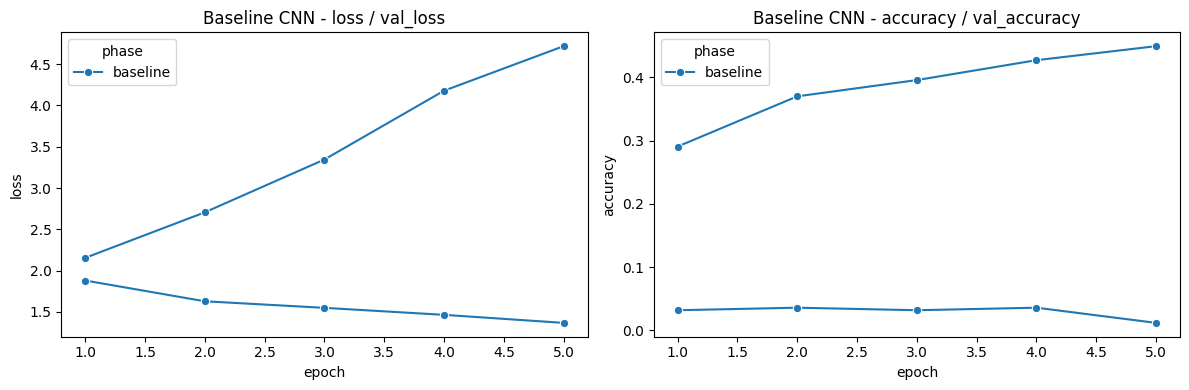

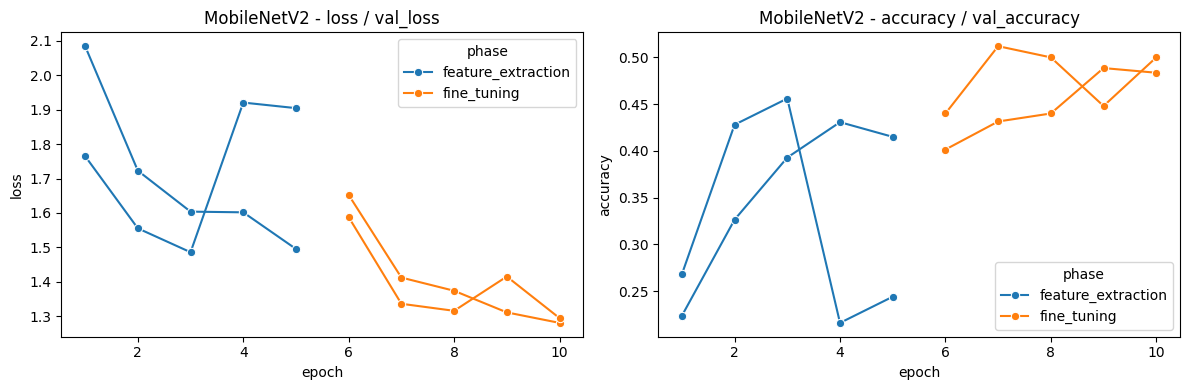

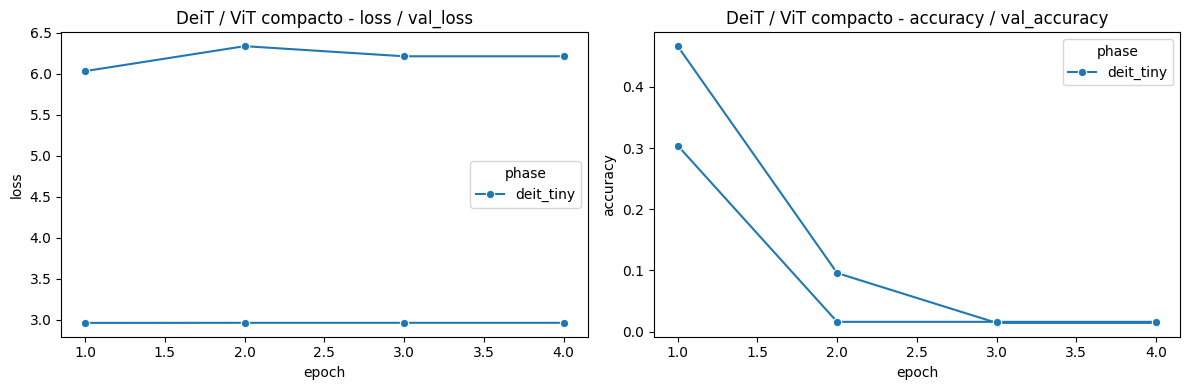

In [24]:
# Curvas de aprendizaje
plot_history(history_to_frame(history_baseline, "baseline"), "Baseline CNN")
plot_history(merge_histories(history_mobilenet_fe, history_mobilenet_ft), "MobileNetV2")
if history_deit is not None:
    plot_history(history_to_frame(history_deit, deit_family), "DeiT / ViT compacto")


In [25]:
# Evaluación de todos los modelos
all_results = []

baseline_results = evaluate_keras_model(
    baseline_model, test_ds_baseline, class_names, mel_idx, model_family="baseline_cnn"
)
all_results.append(baseline_results)

mobilenet_fe_results = evaluate_keras_model(
    mobilenet_fe_snapshot, test_ds_mobilenet, class_names, mel_idx, model_family="mobilenetv2_feature_extraction"
)
all_results.append(mobilenet_fe_results)

mobilenet_ft_results = evaluate_keras_model(
    mobilenet_ft_model, test_ds_mobilenet, class_names, mel_idx, model_family="mobilenetv2_finetuned"
)
all_results.append(mobilenet_ft_results)

if RUN_HYBRID_RF and hybrid_results is not None:
    all_results.append(evaluate_hybrid_rf(hybrid_results, mel_idx))

if deit_model is not None:
    deit_results = evaluate_keras_model(
        deit_model, test_ds_deit, class_names, mel_idx, model_family=deit_family
    )
    all_results.append(deit_results)

# benchmarks de inferencia para modelos keras
for result in all_results:
    if result["model_family"] == "baseline_cnn":
        total_s, ms_img = benchmark_inference_time(baseline_model, test_ds_baseline)
        result["benchmark_seconds"] = total_s
        result["ms_per_image"] = ms_img
    elif result["model_family"] == "mobilenetv2_feature_extraction":
        total_s, ms_img = benchmark_inference_time(mobilenet_fe_snapshot, test_ds_mobilenet)
        result["benchmark_seconds"] = total_s
        result["ms_per_image"] = ms_img
    elif result["model_family"] == "mobilenetv2_finetuned":
        total_s, ms_img = benchmark_inference_time(mobilenet_ft_model, test_ds_mobilenet)
        result["benchmark_seconds"] = total_s
        result["ms_per_image"] = ms_img
    elif result["model_family"] in {"deit_tiny", "small_vit"} and deit_model is not None:
        total_s, ms_img = benchmark_inference_time(deit_model, test_ds_deit)
        result["benchmark_seconds"] = total_s
        result["ms_per_image"] = ms_img
    else:
        result["benchmark_seconds"] = np.nan
        result["ms_per_image"] = np.nan

comparison = pd.DataFrame([{
    "model_name": r["model_name"],
    "model_family": r["model_family"],
    "accuracy": r["accuracy"],
    "macro_f1": r["macro_f1"],
    "macro_precision": r["macro_precision"],
    "macro_recall": r["macro_recall"],
    "balanced_accuracy": r["balanced_accuracy"],
    "mel_precision": r["mel_precision"],
    "mel_recall": r["mel_recall"],
    "mel_f1": r["mel_f1"],
    "params": r["params"],
    "ms_per_image": r["ms_per_image"],
} for r in all_results]).sort_values(["macro_f1", "mel_recall"], ascending=False)

display(comparison)


,model_name,model_family,accuracy,macro_f1,macro_precision,macro_recall,balanced_accuracy,mel_precision,mel_recall,mel_f1,params,ms_per_image
2,mobilenetv2_feature_extraction,mobilenetv2_finetuned,0.568,0.354590,0.348871,0.508572,0.508572,0.304348,0.500000,0.378378,2266951.0,3.186609
1,mobilenetv2_feature_extraction,mobilenetv2_feature_extraction,0.490,0.284321,0.377876,0.421668,0.421668,0.277027,0.732143,0.401961,2266951.0,3.214519
3,mobilenetv2_embeddings_random_forest,random_forest_on_embeddings,0.672,0.136607,0.381526,0.154383,0.154383,0.000000,0.000000,0.000000,NaN,NaN
4,dei_t_image_classifier,deit_tiny,0.300,0.093369,0.117790,0.149090,0.149090,0.119403,0.714286,0.204604,5526151.0,7.746389
0,baseline_cnn_28x28,baseline_cnn,0.032,0.008859,0.004571,0.142857,0.142857,0.000000,0.000000,0.000000,95047.0,2.013777


## 5. Matrices de confusión lado a lado

Esto responde directamente a uno de los entregables del taller.


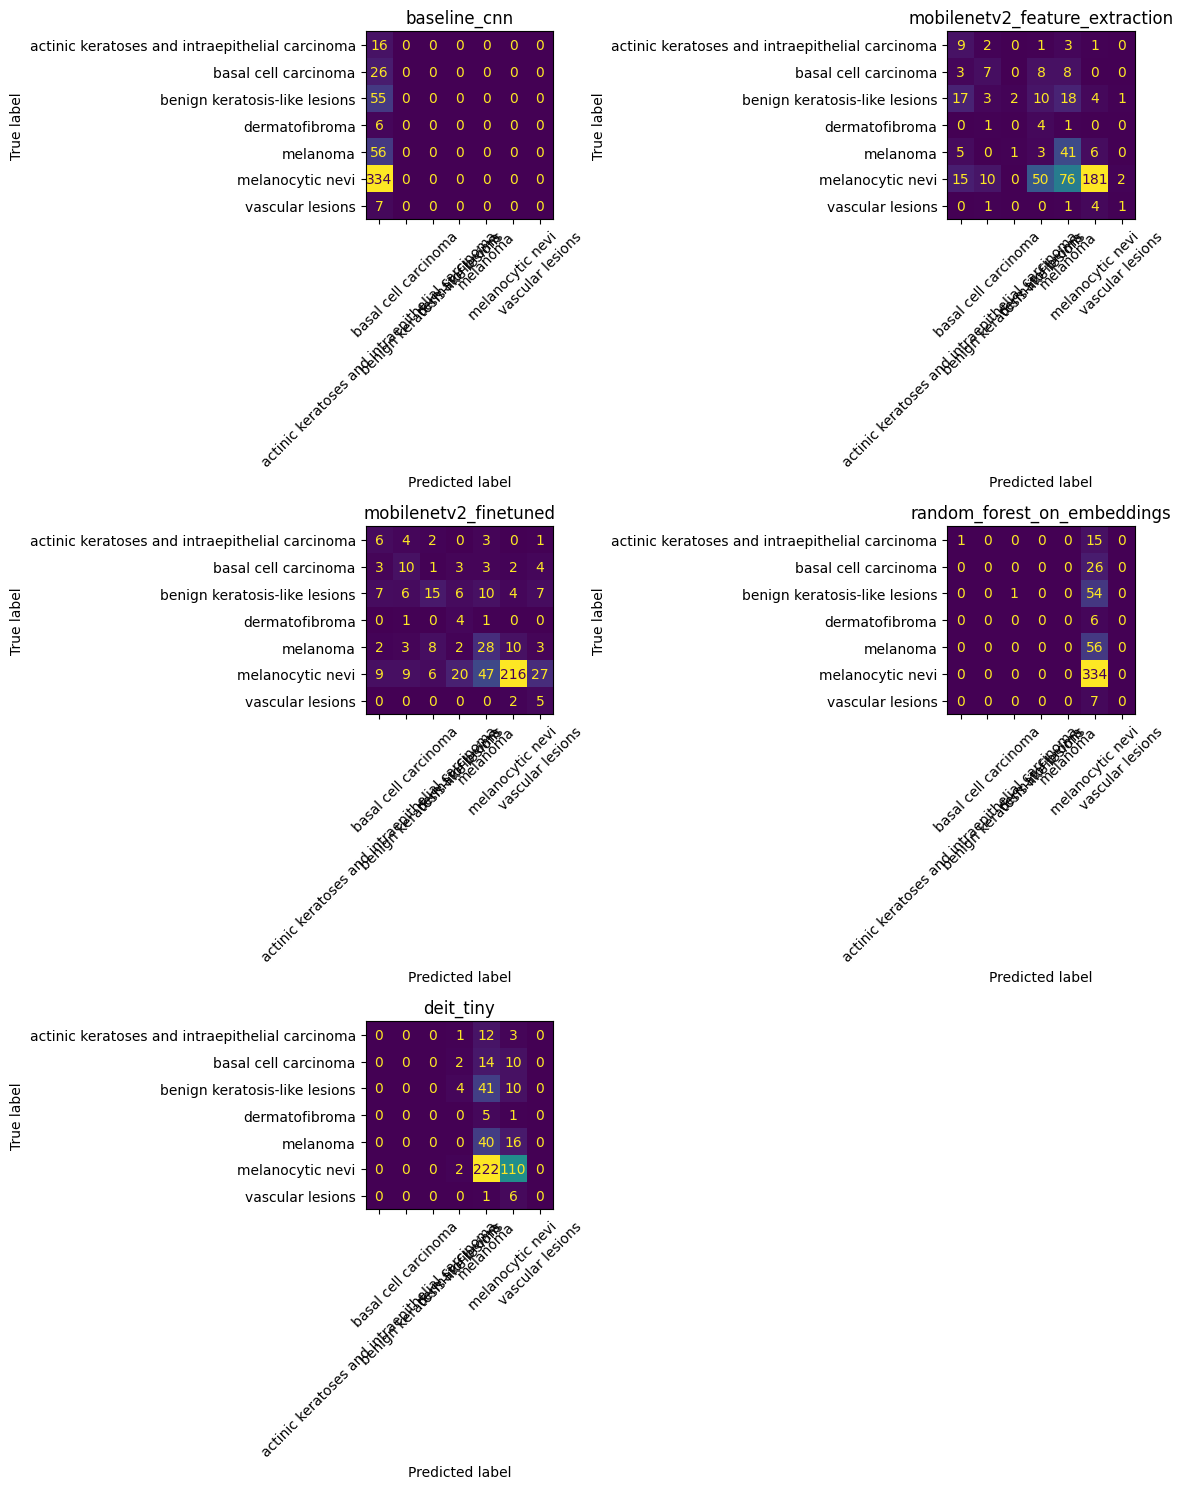

In [26]:
def plot_confusion_side_by_side(results_list, class_names, ncols=2):
    n = len(results_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, result in zip(axes, results_list):
        cm = confusion_matrix(result["y_true"], result["y_pred"], labels=np.arange(len(class_names)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
        ax.set_title(result["model_family"])

    for ax in axes[len(results_list):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_confusion_side_by_side(all_results, class_names)


## 6. Trade-off computacional

Para despliegue móvil interesa ponderar:

- **F1 macro**,
- **recall en melanoma**,
- **número de parámetros**,
- **tiempo de inferencia por imagen**.


In [27]:
tradeoff_df = comparison.copy()

# normalizaciones simples para un score de despliegue
eps = 1e-8
for col in ["macro_f1", "mel_recall"]:
    mn, mx = tradeoff_df[col].min(), tradeoff_df[col].max()
    tradeoff_df[f"{col}_norm"] = (tradeoff_df[col] - mn) / (mx - mn + eps)

for col in ["params", "ms_per_image"]:
    valid = tradeoff_df[col].dropna()
    mn, mx = valid.min(), valid.max()
    tradeoff_df[f"{col}_norm_inv"] = 1.0 - ((tradeoff_df[col] - mn) / (mx - mn + eps))

# score de despliegue: prioriza F1 macro y recall melanoma, sin ignorar costo
tradeoff_df["deployment_score"] = (
    0.40 * tradeoff_df["macro_f1_norm"] +
    0.35 * tradeoff_df["mel_recall_norm"] +
    0.15 * tradeoff_df["params_norm_inv"].fillna(0.0) +
    0.10 * tradeoff_df["ms_per_image_norm_inv"].fillna(0.0)
)

tradeoff_df = tradeoff_df.sort_values("deployment_score", ascending=False)
display(tradeoff_df[[
    "model_family", "macro_f1", "mel_recall", "params", "ms_per_image", "deployment_score"
]])


,model_family,macro_f1,mel_recall,params,ms_per_image,deployment_score
1,mobilenetv2_feature_extraction,0.284321,0.732143,2266951.0,3.214519,0.837770
2,mobilenetv2_finetuned,0.354590,0.500000,2266951.0,3.186609,0.808580
4,deit_tiny,0.093369,0.714286,5526151.0,7.746389,0.439239
0,baseline_cnn,0.008859,0.000000,95047.0,2.013777,0.250000
3,random_forest_on_embeddings,0.136607,0.000000,NaN,NaN,0.147800


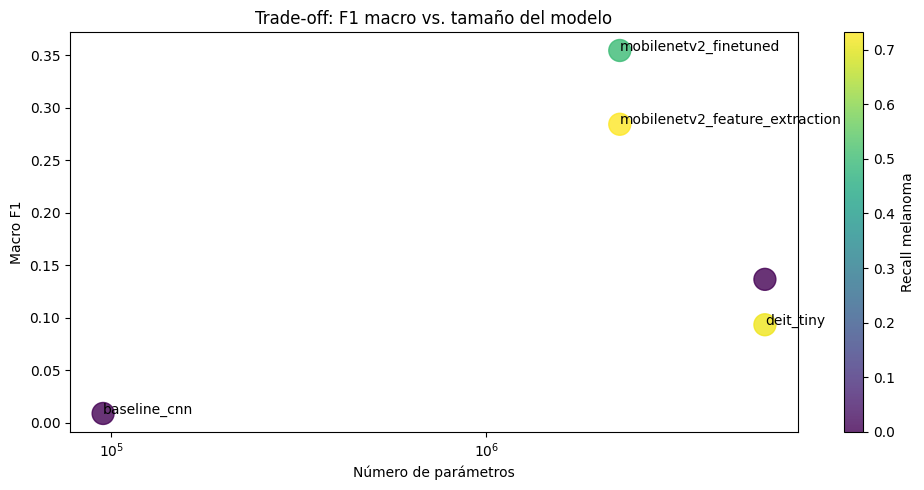

In [28]:
plt.figure(figsize=(10, 5))
scatter = plt.scatter(
    comparison["params"].fillna(comparison["params"].max()),
    comparison["macro_f1"],
    s=250,
    c=comparison["mel_recall"],
    alpha=0.8
)
for _, row in comparison.iterrows():
    plt.annotate(row["model_family"], (row["params"] if pd.notnull(row["params"]) else 0, row["macro_f1"]))
plt.xscale("symlog")
plt.xlabel("Número de parámetros")
plt.ylabel("Macro F1")
plt.title("Trade-off: F1 macro vs. tamaño del modelo")
plt.colorbar(scatter, label="Recall melanoma")
plt.tight_layout()
plt.show()


## 7. Comparación explícita: Feature Extraction vs. Fine-Tuning

Aquí revisamos si el fine-tuning mejoró respecto a dejar la base congelada.


In [29]:
fe_ft_compare = comparison[comparison["model_family"].isin([
    "mobilenetv2_feature_extraction",
    "mobilenetv2_finetuned"
])][[
    "model_family", "accuracy", "macro_f1", "mel_precision", "mel_recall", "mel_f1", "params", "ms_per_image"
]]
display(fe_ft_compare)


,model_family,accuracy,macro_f1,mel_precision,mel_recall,mel_f1,params,ms_per_image
2,mobilenetv2_finetuned,0.568,0.354590,0.304348,0.500000,0.378378,2266951.0,3.186609
1,mobilenetv2_feature_extraction,0.490,0.284321,0.277027,0.732143,0.401961,2266951.0,3.214519


## 8. ¿Mejoró la detección de melanoma frente al Caso 01?

Como aproximación al **Caso 01**, tomamos la **CNN baseline desde cero** y la comparamos contra los modelos con transfer learning.


In [30]:
baseline_mel = comparison.loc[comparison["model_family"] == "baseline_cnn", "mel_recall"].iloc[0]
improvement_df = comparison.copy()
improvement_df["delta_mel_recall_vs_baseline"] = improvement_df["mel_recall"] - baseline_mel
display(improvement_df[[
    "model_family", "mel_recall", "delta_mel_recall_vs_baseline", "macro_f1", "macro_precision"
]].sort_values("delta_mel_recall_vs_baseline", ascending=False))


,model_family,mel_recall,delta_mel_recall_vs_baseline,macro_f1,macro_precision
1,mobilenetv2_feature_extraction,0.732143,0.732143,0.284321,0.377876
4,deit_tiny,0.714286,0.714286,0.093369,0.117790
2,mobilenetv2_finetuned,0.500000,0.500000,0.354590,0.348871
3,random_forest_on_embeddings,0.000000,0.000000,0.136607,0.381526
0,baseline_cnn,0.000000,0.000000,0.008859,0.004571


## 9. Selección y exportación del mejor modelo para despliegue

Para el archivo `.keras` y el `predict.py`, elegimos el mejor modelo **keras** según el `deployment_score`.


In [31]:
keras_candidates = tradeoff_df[tradeoff_df["model_family"].isin([
    "baseline_cnn", "mobilenetv2_feature_extraction", "mobilenetv2_finetuned", "deit_tiny", "small_vit"
])].copy()

winner_family = keras_candidates.iloc[0]["model_family"]
print("Ganador para despliegue:", winner_family)

family_to_model = {
    "baseline_cnn": baseline_model,
    "mobilenetv2_feature_extraction": mobilenet_fe_snapshot,
    "mobilenetv2_finetuned": mobilenet_ft_model,
    "deit_tiny": deit_model,
    "small_vit": deit_model,
}
best_model = family_to_model[winner_family]

best_model_path = EXPORT_DIR / "best_model.keras"
best_meta_path = EXPORT_DIR / "best_model_meta.json"

best_model.save(best_model_path)

best_meta = {
    "data_flag": DATA_FLAG,
    "source_size": SOURCE_SIZE,
    "target_size": TARGET_SIZE if winner_family != "baseline_cnn" else SOURCE_SIZE,
    "selected_interpolation": SELECTED_INTERPOLATION,
    "winner_family": winner_family,
    "class_names": class_names,
    "mel_class_index": int(mel_idx),
    "model_preprocessing": {
        "baseline_cnn": "rescale_0_1",
        "mobilenetv2_feature_extraction": "mobilenet_v2",
        "mobilenetv2_finetuned": "mobilenet_v2",
        "deit_tiny": "raw_0_255_with_internal_preprocessor",
        "small_vit": "raw_0_255",
    }[winner_family],
}

with open(best_meta_path, "w", encoding="utf-8") as f:
    json.dump(best_meta, f, ensure_ascii=False, indent=2)

print("Modelo exportado en:", best_model_path)
print("Metadata exportada en:", best_meta_path)


Ganador para despliegue: mobilenetv2_feature_extraction
Modelo exportado en: artifacts_taller_02/best_model.keras
Metadata exportada en: artifacts_taller_02/best_model_meta.json


## 10. Generar `predict.py`


In [32]:
predict_script = r'''import argparse
import json
from pathlib import Path

import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# soporte para Small ViT fallback
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return cfg

def load_model_with_context(model_path, family):
    if family == "deit_tiny":
        import keras_hub  # noqa: F401
    custom_objects = {
        "Patches": Patches,
        "PatchEncoder": PatchEncoder,
    }
    return keras.models.load_model(model_path, custom_objects=custom_objects, compile=False)

def pil_resample(method_name):
    method_name = method_name.lower()
    if method_name == "bicubic":
        return Image.Resampling.BICUBIC
    if method_name == "bilinear":
        return Image.Resampling.BILINEAR
    return Image.Resampling.BILINEAR

def preprocess_image(image_path, meta):
    img = Image.open(image_path).convert("RGB")

    # el enunciado dice imagen cruda 28x28; si no llega así, la adaptamos primero a SOURCE_SIZE
    source_size = meta["source_size"]
    target_size = meta["target_size"]
    interpolation = meta["selected_interpolation"]

    img = img.resize((source_size, source_size), Image.Resampling.BILINEAR)

    if target_size != source_size:
        img = img.resize((target_size, target_size), pil_resample(interpolation))

    arr = np.array(img).astype("float32")
    arr = np.expand_dims(arr, axis=0)

    preprocessing = meta["model_preprocessing"]
    if preprocessing == "rescale_0_1":
        arr = arr / 255.0
    elif preprocessing == "mobilenet_v2":
        arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    elif preprocessing in {"raw_0_255", "raw_0_255_with_internal_preprocessor"}:
        pass
    else:
        raise ValueError(f"Preprocesamiento desconocido: {preprocessing}")

    return arr

def main():
    parser = argparse.ArgumentParser(description="Inferencia para DermaMNIST / Taller 02")
    parser.add_argument("--image", required=True, help="Ruta a la imagen cruda")
    parser.add_argument("--model", default="artifacts_taller_02/best_model.keras", help="Ruta al modelo .keras")
    parser.add_argument("--meta", default="artifacts_taller_02/best_model_meta.json", help="Ruta al metadata JSON")
    args = parser.parse_args()

    with open(args.meta, "r", encoding="utf-8") as f:
        meta = json.load(f)

    model = load_model_with_context(args.model, meta["winner_family"])
    x = preprocess_image(args.image, meta)

    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_name = meta["class_names"][pred_idx]

    print(json.dumps({
        "predicted_index": pred_idx,
        "predicted_label": pred_name,
        "top3": [
            {"label": meta["class_names"][i], "prob": float(probs[i])}
            for i in np.argsort(probs)[::-1][:3]
        ]
    }, ensure_ascii=False, indent=2))

if __name__ == "__main__":
    main()'''
predict_path = EXPORT_DIR / "predict.py"
with open(predict_path, "w", encoding="utf-8") as f:
    f.write(predict_script)
print("Script generado en:", predict_path)


Script generado en: artifacts_taller_02/predict.py


## 11. Conclusiones sugeridas para el informe

1. **Interpolación**: la elección entre bilinear y bicubic no es neutral; cambia la suavidad, el borde aparente y el contenido de alta frecuencia.
2. **Feature extraction vs. fine-tuning**: congelar la base suele converger más rápido; hacer fine-tuning suele mejorar adaptación dermatológica, pero puede sobreajustar si no se controla.
3. **Trade-off móvil**: no siempre gana el modelo con mayor F1; para despliegue real pesan parámetros e inferencia.
4. **Melanoma**: la métrica crítica no es solo accuracy global; importa especialmente el **recall de `mel`**.
5. **Híbrido**: usar embeddings de una CNN pre-entrenada con Random Forest puede ser un baseline opcional interesante.
